_# Ordinal Data
Feature reduction, redundancy and feature engineering

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from IPython.core.pylabtools import figsize
from sympy.abc import alpha

data = pd.read_csv("Data/ordinal_train_cleaned.csv")
X = data.drop('SalePrice', axis=1)
y = data['SalePrice']

X

,OverallQual,OverallQual.1,OverallCond,MSSubClass,ExterQual,ExterCond,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,...,HeatingQC,KitchenQual,FireplaceQu,GarageFinish,GarageQual,GarageCond,LotShape,LandSlope,LandContour,SaleCondition
0,7,7,5,60,4,3,4,3,1,6,...,5,4,4,2,3,3,3,2,3,4
1,6,6,8,20,3,3,4,3,4,5,...,5,3,3,2,3,3,3,2,3,4
2,7,7,5,60,4,3,4,3,2,6,...,5,4,3,2,3,3,2,2,3,4
3,7,7,5,70,3,3,3,4,1,5,...,4,4,4,1,3,3,2,2,3,0
4,8,8,5,60,4,3,4,3,3,6,...,5,4,3,2,3,3,2,2,3,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1407,6,6,5,60,3,3,4,3,1,1,...,5,3,3,2,3,3,3,2,3,4
1408,6,6,6,20,3,3,4,3,1,5,...,3,3,3,1,3,3,3,2,3,4
1409,7,7,9,70,5,4,3,4,1,6,...,5,4,4,2,3,3,3,2,3,4
1410,5,5,6,20,3,3,3,3,2,6,...,4,4,4,1,3,3,3,2,3,4


# Mutual Information Score
as first feature reduction criterion

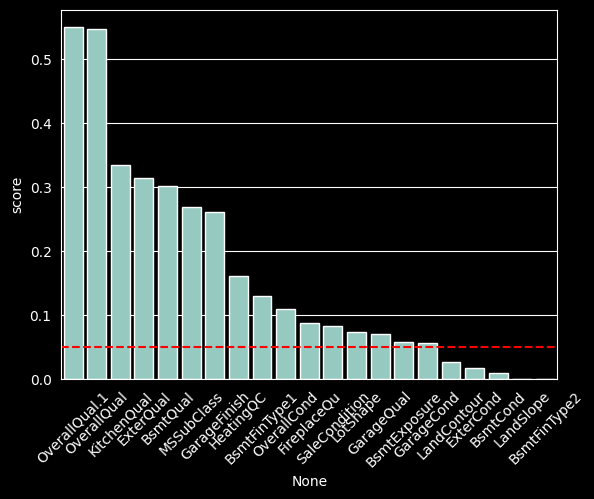

In [2]:
from sklearn.feature_selection import mutual_info_regression

mi = mutual_info_regression(X, y)
mi_series = pd.Series(mi, index=X.columns, name='score').sort_values(ascending=False)

sns.barplot(x=mi_series.index, y=mi_series.sort_values(ascending=False))
plt.xticks(rotation=45)
plt.axhline(y=0.05, color='r', linestyle='--')
plt.show()

And We take those having MI score grater than 0.05

In [3]:
selected_X = X[mi_series[mi_series.values > 0.05].keys()]
removed_x = X[mi_series[mi_series.values < 0.05].keys()]

selected_X

,OverallQual.1,OverallQual,KitchenQual,ExterQual,BsmtQual,MSSubClass,GarageFinish,HeatingQC,BsmtFinType1,OverallCond,FireplaceQu,SaleCondition,LotShape,GarageQual,BsmtExposure,GarageCond
0,7,7,4,4,4,60,2,5,6,5,4,4,3,3,1,3
1,6,6,3,3,4,20,2,5,5,8,3,4,3,3,4,3
2,7,7,4,4,4,60,2,5,6,5,3,4,2,3,2,3
3,7,7,4,3,3,70,1,4,5,5,4,0,2,3,1,3
4,8,8,4,4,4,60,2,5,6,5,3,4,2,3,3,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1407,6,6,3,3,4,60,2,5,1,5,3,4,3,3,1,3
1408,6,6,3,3,4,20,1,3,5,6,3,4,3,3,1,3
1409,7,7,4,5,3,70,2,5,6,9,4,4,3,3,1,3
1410,5,5,4,3,3,20,1,4,6,6,4,4,3,3,2,3


# Vizualizations
with target

## Selected X
to check if categories are correlated with target

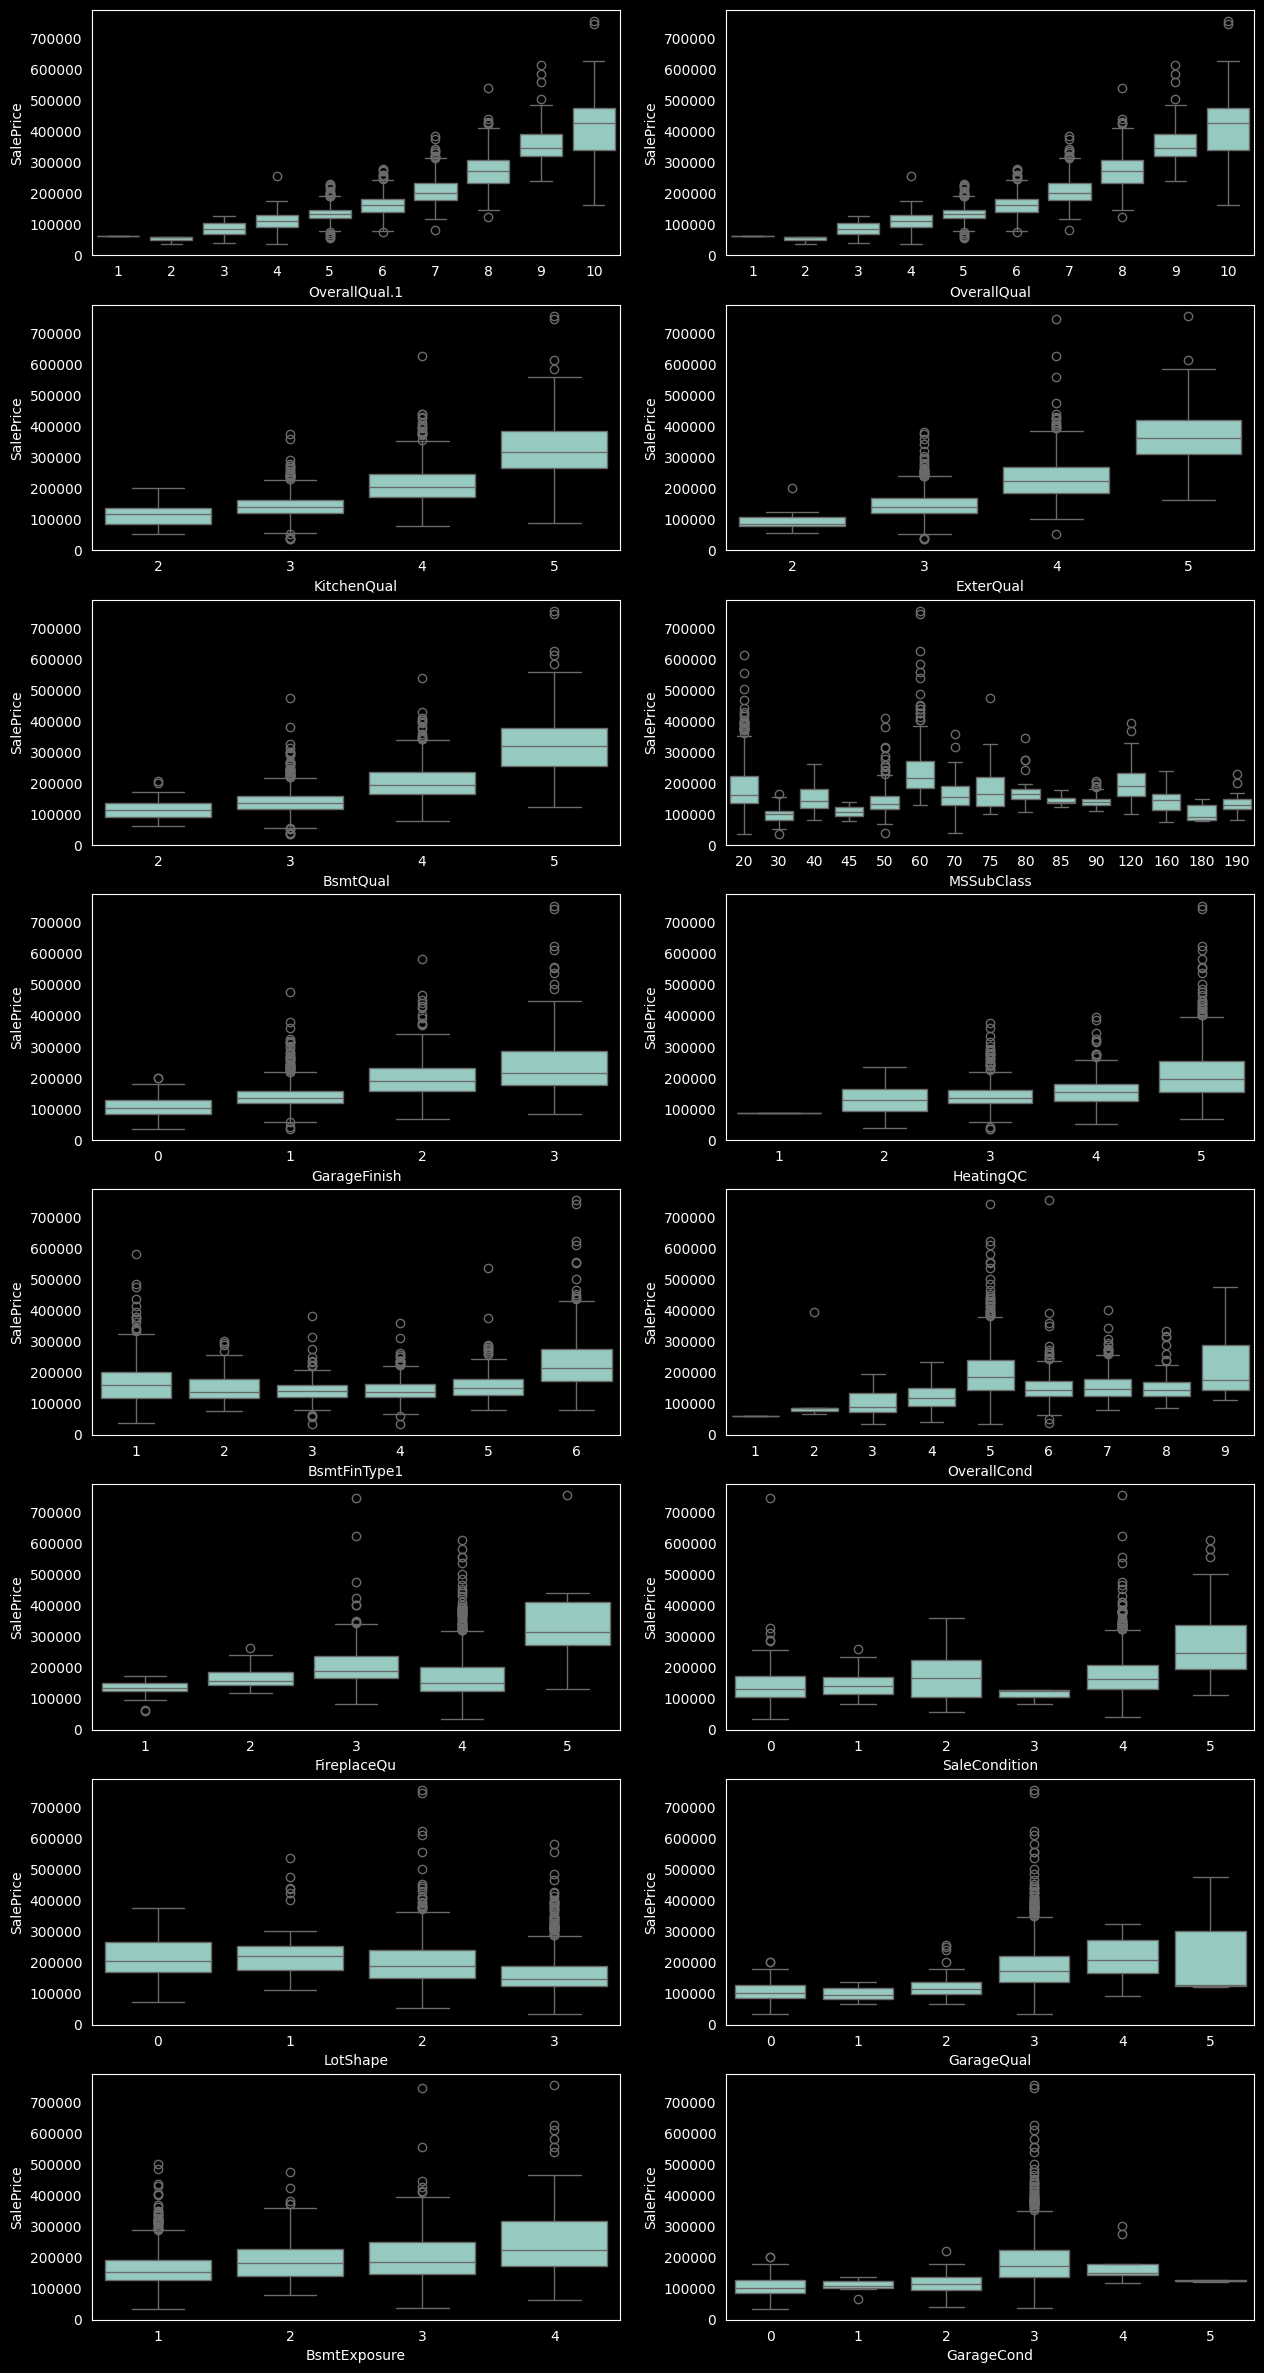

In [4]:
fig, ax = plt.subplots(8,2, figsize=(15,30))
ax = ax.flatten()

for idx, col in enumerate(selected_X.columns):
    sns.boxplot(data=data, x=col, y='SalePrice', ax=ax[idx])
    ax[idx].grid(False)


## Unselected X

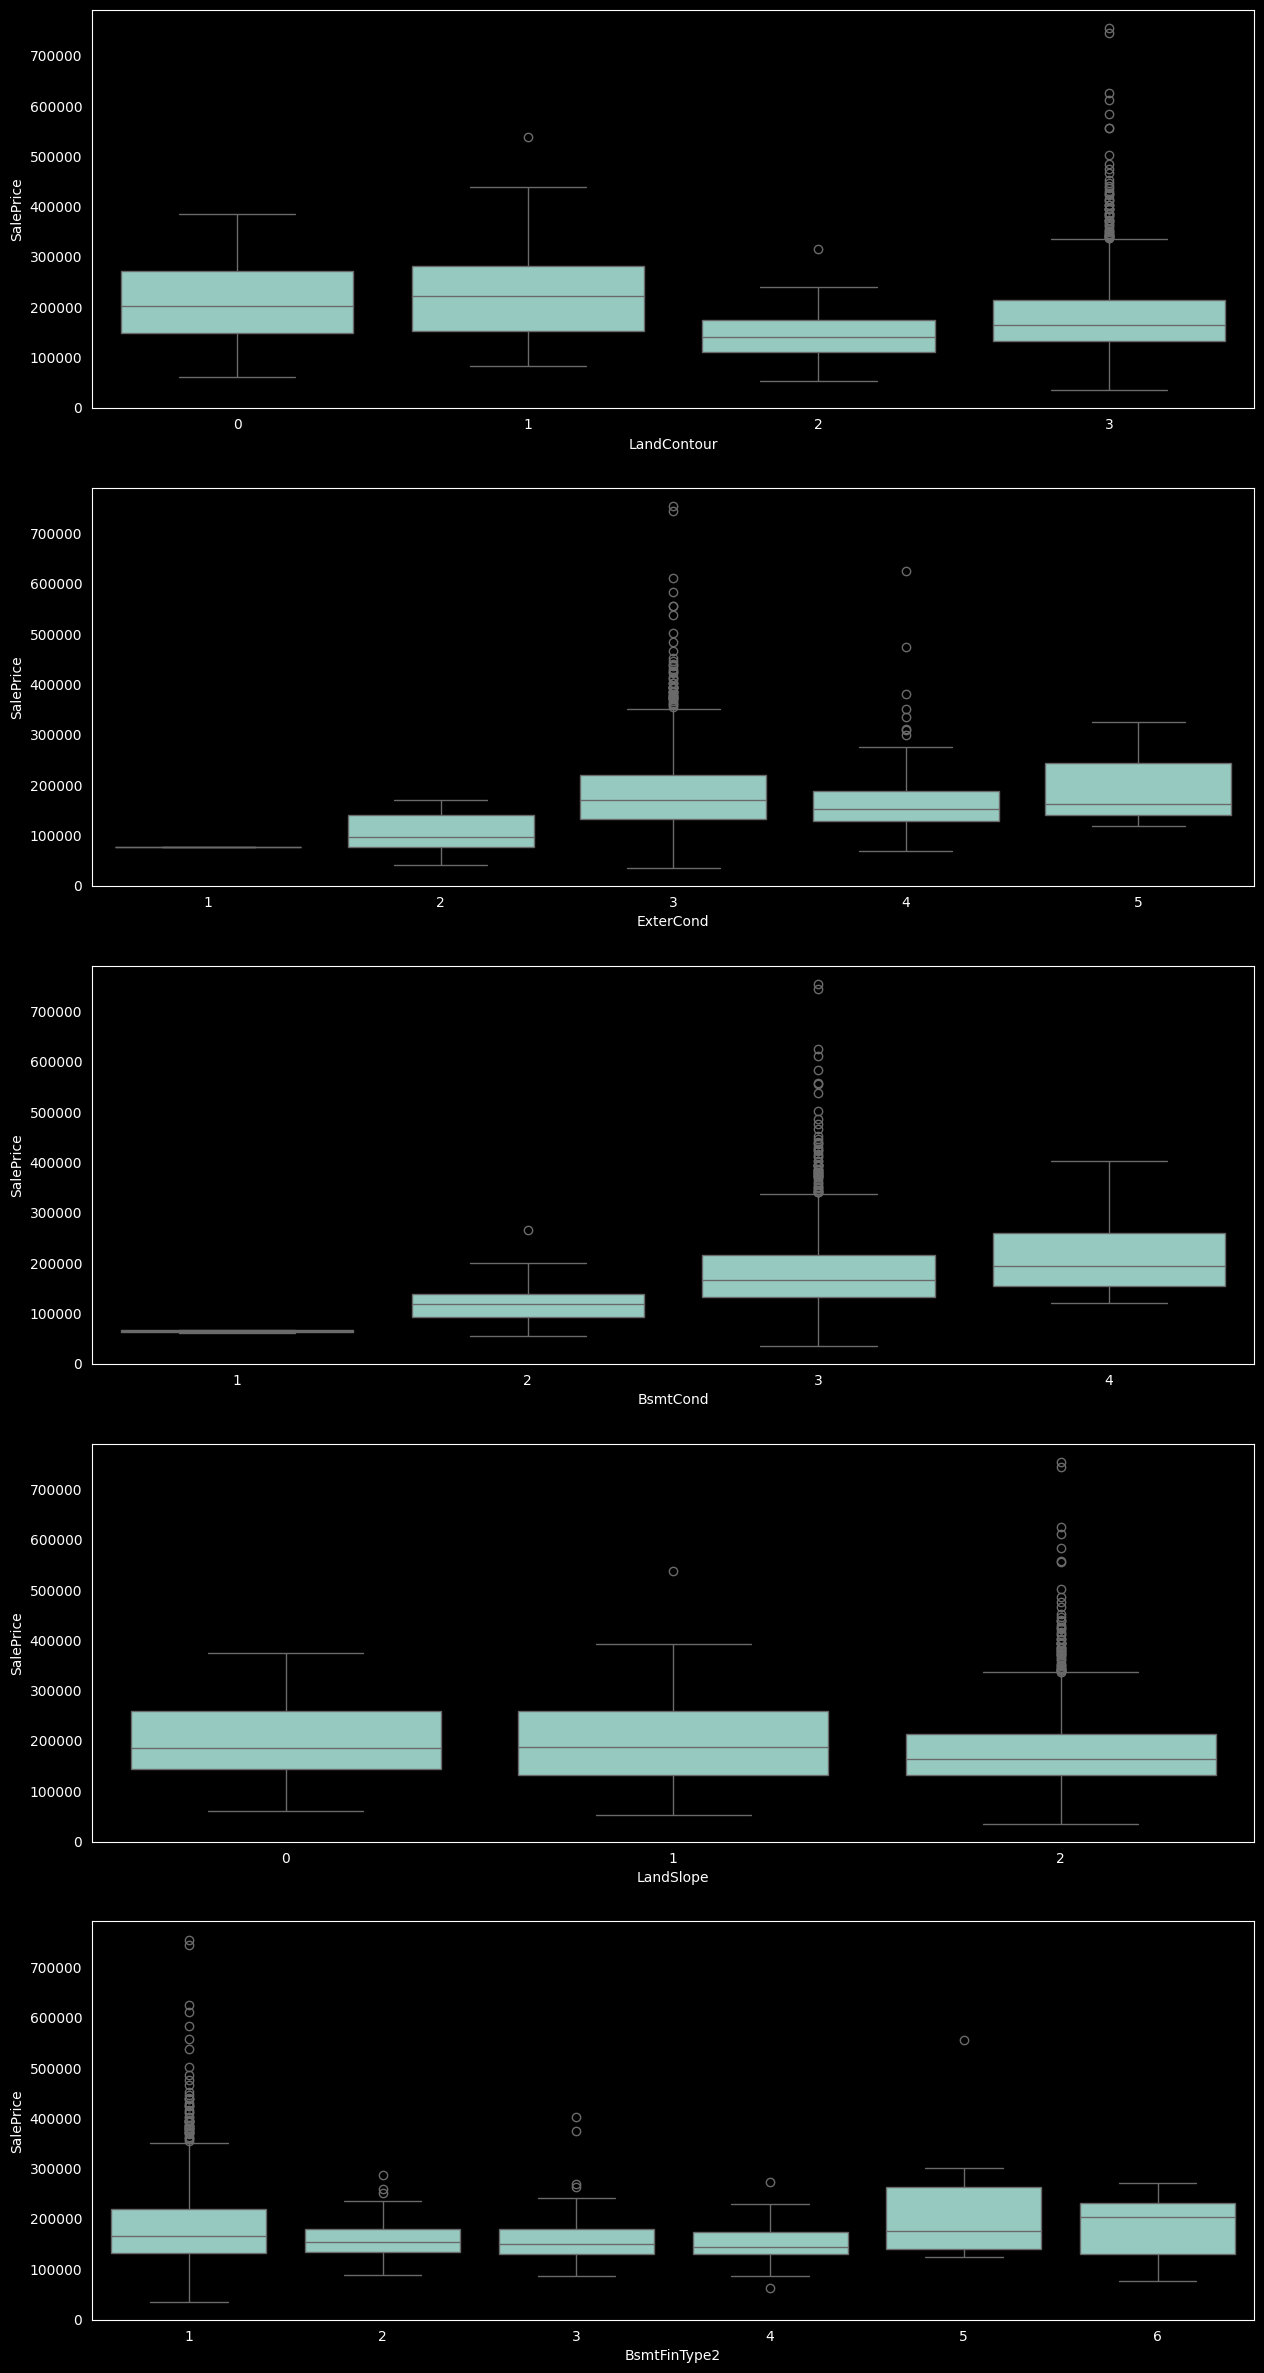

In [5]:
fig, ax = plt.subplots(5,1, figsize=(15,30))
ax = ax.flatten()

for idx, col in enumerate(removed_x.columns):
    sns.boxplot(data=data, x=col, y='SalePrice', ax=ax[idx])
    ax[idx].grid(False)


## Additional reduction
Basing on plots and analyzing correlation with target `BsmtQual` is removed. Rest stays the same.


In [6]:
new_X = selected_X.drop('BsmtQual', axis=1)

##  Correlation

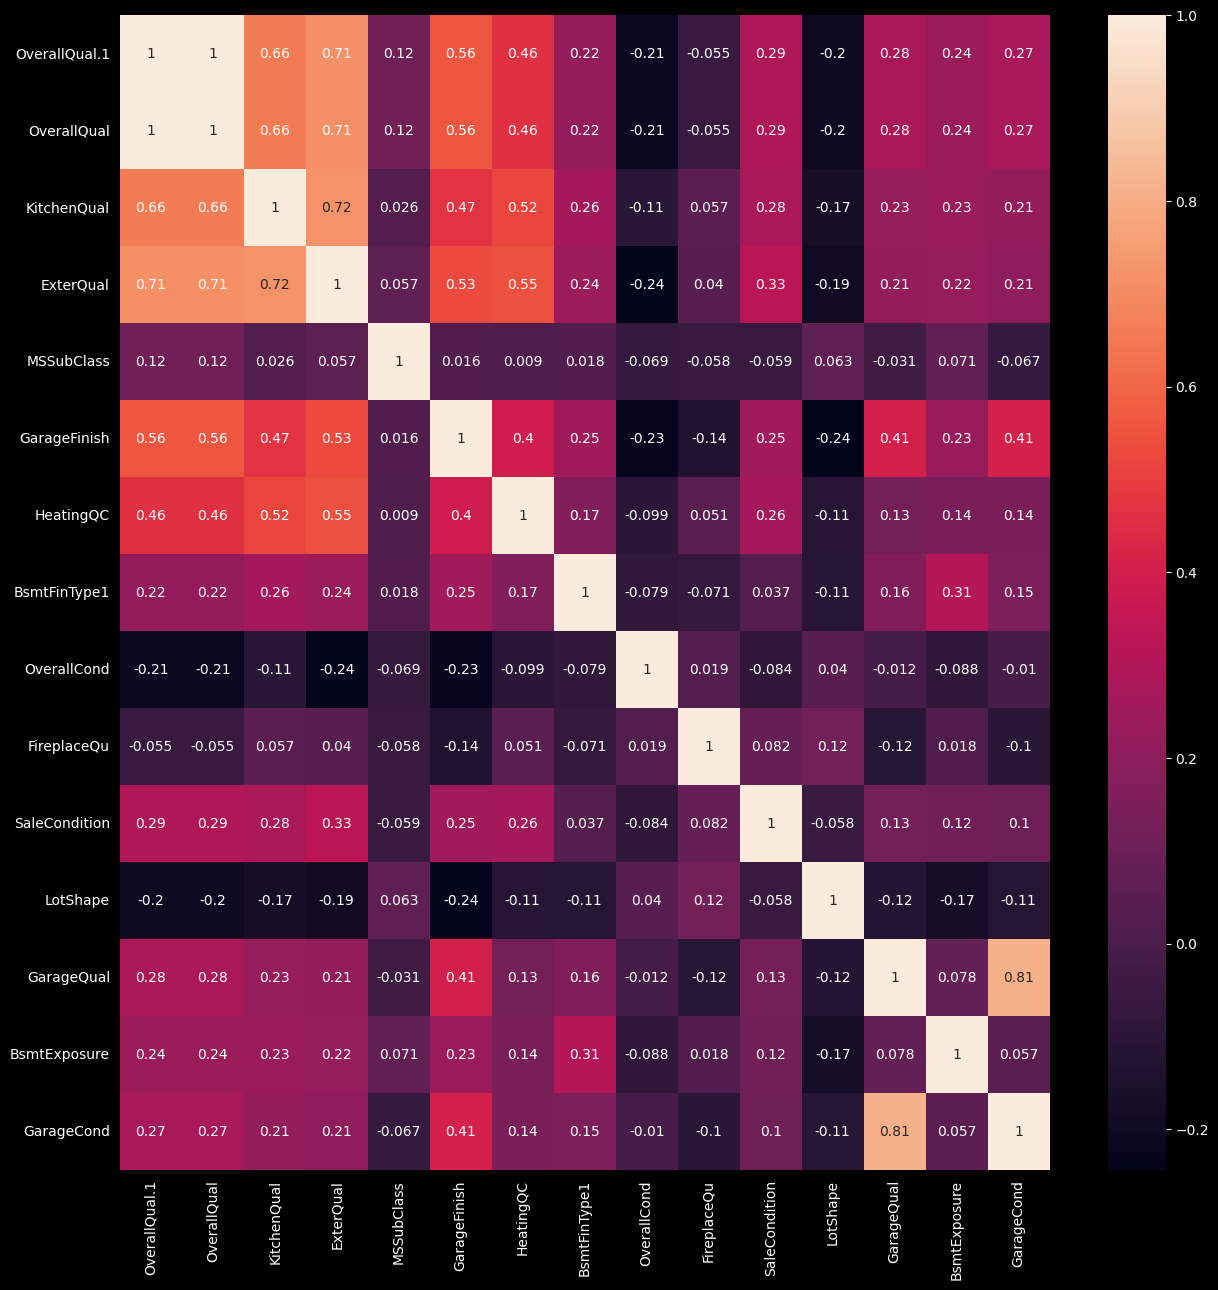

In [7]:
corr_mtx = new_X.corr(method='spearman')

plt.figure(figsize=(15,15))
sns.heatmap(corr_mtx, annot=True)
plt.show()

### Removing highly corralated features

In [8]:
uncor_x = new_X.drop(['OverallQual','GarageCond' ], axis=1)

uncor_x

,OverallQual.1,KitchenQual,ExterQual,MSSubClass,GarageFinish,HeatingQC,BsmtFinType1,OverallCond,FireplaceQu,SaleCondition,LotShape,GarageQual,BsmtExposure
0,7,4,4,60,2,5,6,5,4,4,3,3,1
1,6,3,3,20,2,5,5,8,3,4,3,3,4
2,7,4,4,60,2,5,6,5,3,4,2,3,2
3,7,4,3,70,1,4,5,5,4,0,2,3,1
4,8,4,4,60,2,5,6,5,3,4,2,3,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1407,6,3,3,60,2,5,1,5,3,4,3,3,1
1408,6,3,3,20,1,3,5,6,3,4,3,3,1
1409,7,4,5,70,2,5,6,9,4,4,3,3,1
1410,5,4,3,20,1,4,6,6,4,4,3,3,2


# PCA Analysis

In [31]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler


pca = PCA(n_components=4)

scaler = StandardScaler()
x_scaled = scaler.fit_transform(uncor_x)
x_scaled = pd.DataFrame(x_scaled, columns=uncor_x.columns, index=uncor_x.index)
pca.fit(x_scaled)


df_components = pd.DataFrame()

df_PCA = pd.DataFrame(pca.components_.T, index=x_scaled.columns, columns = ['PC1', 'PC2', 'PC3', 'PC4']).sort_values(by='PC1', ascending=False)
df_PCA

,PC1,PC2,PC3,PC4
ExterQual,0.436460,0.209743,0.031284,-0.030797
OverallQual.1,0.433557,0.109836,0.004825,-0.078699
KitchenQual,0.418106,0.213425,-0.002110,0.068678
GarageFinish,0.388439,-0.219150,-0.108494,-0.224599
HeatingQC,0.330228,0.266557,-0.076821,0.014210
GarageQual,0.223976,-0.324586,-0.364532,-0.277778
BsmtExposure,0.206776,-0.232091,0.438859,0.412951
BsmtFinType1,0.186949,-0.327394,0.341695,0.324423
SaleCondition,0.153968,0.064019,-0.260409,-0.004183
FireplaceQu,0.015513,0.593123,0.061474,0.312283


## Plotting

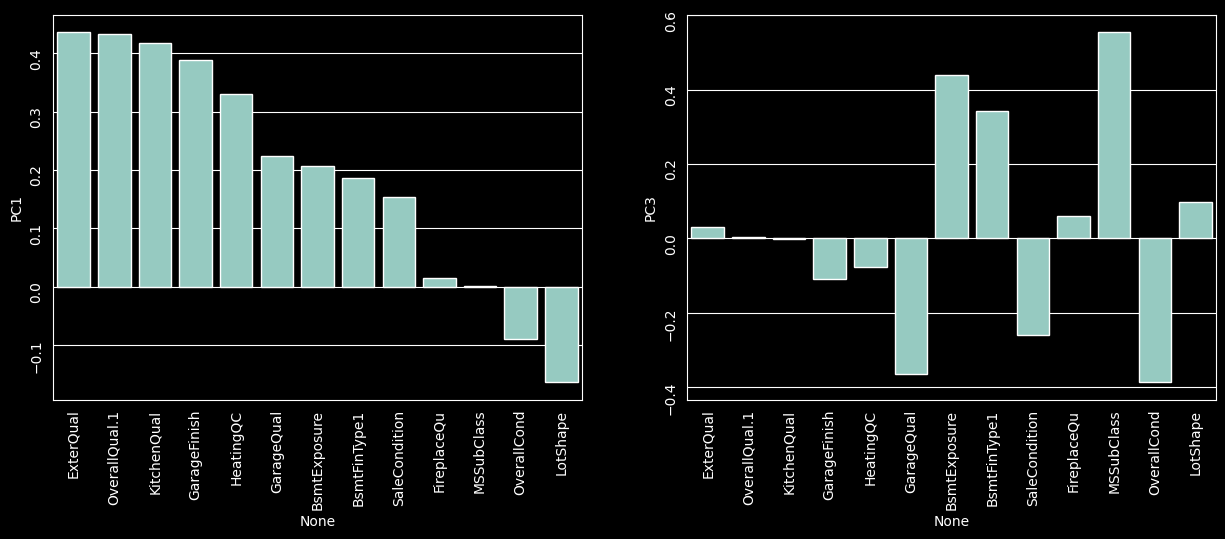

In [45]:
fig, ax = plt.subplots(1,2, figsize = (15,5))
ax=ax.flatten()
sns.barplot(data = df_PCA, x=df_PCA.index, y='PC1', ax=ax[0])
# sns.barplot(data = df_PCA, x=df_PCA.index, y='PC2', alpha=0.5, color= 'red', ax=ax[0])
ax[0].tick_params(rotation=90)


sns.barplot(data = df_PCA, x=df_PCA.index, y='PC3', ax=ax[1])
# sns.barplot(data = df_PCA, x=df_PCA.index, y='PC4', alpha=0.5, color= 'red', ax=ax[1])
ax[1].tick_params(rotation=90)
plt.show()

# Proposition of new features

In [ ]:
engined_x = pd.DataFrame()
engined_x['']